# Overcomplete local-factor discovery + count selection — Poisson MAP + L1

Two things at once, count-native and at scale:
1. **Overcomplete fit** (`q_fit=50` while only `q_true=25` factors are real) — the spurious
   half should *die* (column collapse), and an **elbow** on the factor strengths should recover
   the true count.
2. **Each real factor is local** — it wires ~K of P genes, not all of them. So within the
   surviving factors we also recover *which* genes form each small program.

Estimator: plain **stochastic proximal gradient** on the loadings (SGD → small L2 shrink → L1
soft-threshold), support read off the de-noised averaged gradient (`|ḡ_j| > λ₁`, lr-free). This
is **discovery, not inference** — a robust support and factor count, not calibrated SEs.

- **`MapEncoderPoissonNewton`** — Poisson MAP z̃
- **`SparseZQEFitter`** — properly-ridged dense warm-start → one prox-gradient sparsify pass
- **no lower-tri** — the sparse supports break the rotation gauge

**Goal**: kill the 25 spurious factors (elbow at 25), and recover each surviving factor's
local gene support.

In [1]:
%load_ext autoreload
%autoreload 2

import os, copy
import numpy as np
import torch
import matplotlib.pyplot as plt

from gllvm.simulations import make_sparse, simulate
from gllvm.autofit import procrustes_error
from gllvm.autofit_sparse import SparseZQEFitter
from gllvm.encoder import MapEncoderPoissonNewton

SEED   = 42
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- experiment config: q_true local factors, fit OVERCOMPLETE, select the count ---
Q_TRUE   = 25     # true factors (each local)
Q_FIT    = 50     # overcomplete fit — ~half the factors should die
P        = 1000   # responses (genes)
N        = 500    # observations (cells)
K        = 20     # responses per factor — each TRUE factor is LOCAL (~K of P genes)
WZ_SCALE = 0.5

# sparse-discovery hyperparams
L1     = 0.05   # selection knob (sweep this for the path / elbow)
L2     = 0.01   # small elastic-net ridge in the sparsify pass

print(f"device={device}  Q_TRUE={Q_TRUE}  Q_FIT={Q_FIT}  P={P}  N={N}  K={K}")
print(f"l1={L1}  l2={L2}")

device=cuda  Q_TRUE=25  Q_FIT=50  P=1000  N=500  K=20
l1=0.05  l2=0.01


## Data

In [2]:
torch.manual_seed(SEED)
g_true = make_sparse(
    n_latent=Q_TRUE, poisson=P, active_latent=Q_TRUE,
    wz_scale=WZ_SCALE, responses_per_latent=K,   # each true factor → ~K genes
).to(device)

Y, _ = simulate(g_true, n_samples=N, device=device)
W_true = g_true.wz.detach().cpu()

nnz_col = (W_true != 0).sum(0).float()
print(f"Y: {Y.shape}   mean count: {Y.float().mean():.2f}")
print(f"W_true: {W_true.shape}  ({Q_TRUE} true factors)  nonzeros/factor: {nnz_col.mean():.0f} (K={K})   "
      f"total zeros: {100*(W_true==0).float().mean():.1f}%")

Y: torch.Size([500, 1000])   mean count: 1.84
W_true: torch.Size([1000, 25])  (25 true factors)  nonzeros/factor: 20 (K=20)   total zeros: 98.0%


## Discover the per-factor supports

`SparseZQEFitter` fits at `q=Q` (all factors alive) and returns `ft.mask_`: which loadings
survive. With local truth, each surviving column should pick out a tight set of ~K genes.

In [3]:
from gllvm.gllvm_module import GLLVM
from gllvm.glms import PoissonGLM

def fresh_model(q, p, wz_scale, seed=0):
    torch.manual_seed(seed)
    g = GLLVM(latent_dim=q, output_dim=p)   # full W — NO lower-tri (sparsity lives in a rotation)
    g.add_glm(PoissonGLM, idx=range(p), params={"T": torch.log1p})
    torch.nn.init.normal_(g.wz, std=wz_scale)
    torch.nn.init.zeros_(g.bias)
    return g.to(device)


def run(l1, l2, label, warm_model=None):
    g = fresh_model(Q_FIT, P, WZ_SCALE)
    ft = SparseZQEFitter(
        g,
        encoder_factory=lambda g: MapEncoderPoissonNewton(g, lam=1.0, max_iter=30),
        l1=l1, l2=l2,
        steps=400, refine_lr=0.2,
        revive_jitter=0.0,           # prune-from-dense direction — no revival needed
        warm_model=warm_model,
        device=device, seed=SEED, verbose=True,
    ).fit(Y)
    W_hat = ft.model.wz.detach().cpu()
    m = ft.mask_.cpu()
    print(f"[{label}]  live factors: {int((m.sum(0)>0).sum())}/{Q_FIT}  (true {Q_TRUE})   "
          f"nonzeros/live factor: {m.sum(0)[m.sum(0)>0].float().mean():.0f}\n")
    return ft, W_hat


ft_l1,    W_l1    = run(l1=L1,  l2=L2, label="L1 (overcomplete + local)")
ft_dense, W_dense = run(l1=0.0, l2=L2, label="no L1 (dense baseline)", warm_model=ft_l1.warm_model_)

[warm-up] adam lr=0.1 (exit at lr≤0.002)


  ep  100  loss=+707.9073  gnorm=25.8252  lr=1.00e-01


  ep  200  loss=+308.9875  gnorm=18.7570  lr=1.00e-01


  ep  300  loss=+76.6510  gnorm=13.1733  lr=5.00e-02


  ep  400  loss=+25.6892  gnorm=10.7977  lr=2.50e-02


...

  step  240/400  loss=-3.1163  λ1=0  lr=0.013  live=50/50  supp-zeros=0%  (iter-zeros=0%)


  step  280/400  loss=-7.0625  λ1=0  lr=0.012  live=50/50  supp-zeros=0%  (iter-zeros=0%)


  step  320/400  loss=-0.1594  λ1=0  lr=0.011  live=50/50  supp-zeros=0%  (iter-zeros=0%)


  step  360/400  loss=-2.9992  λ1=0  lr=0.011  live=50/50  supp-zeros=0%  (iter-zeros=0%)


  step  400/400  loss=-5.1318  λ1=0  lr=0.010  live=50/50  supp-zeros=0%  (iter-zeros=0%)
[done]  live factors 50/50  mask zeros 0%  (→ freeze mask, refit with ZQEAutoFitter for the precise fit)
[no L1 (dense baseline)]  live factors: 50/50  (true 25)   nonzeros/live factor: 1000



## W heatmaps

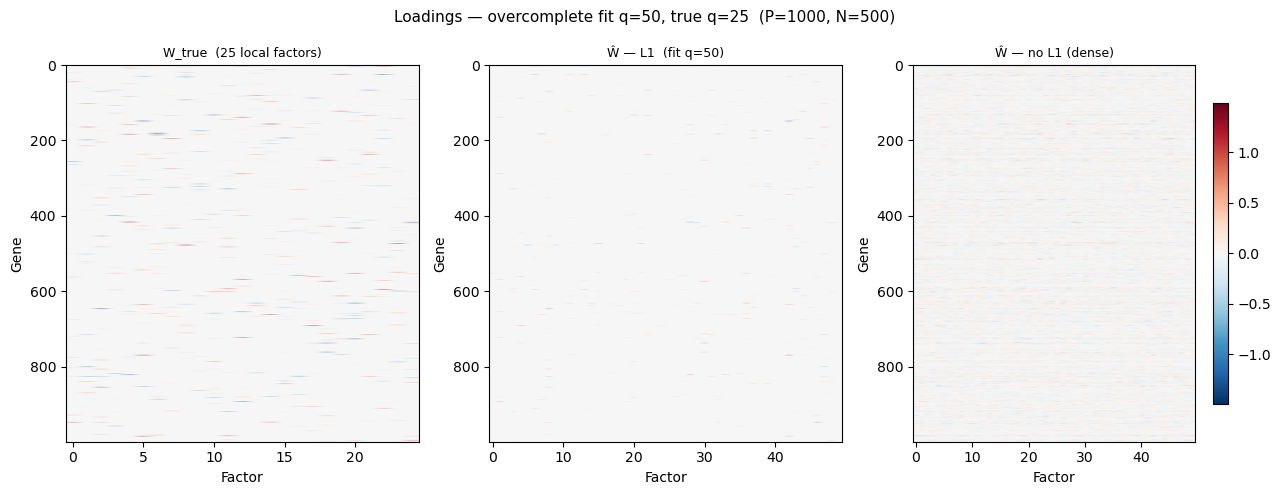

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
vmax = W_true.abs().max().item()

for ax, W, title in zip(axes,
    [W_true, W_l1, W_dense],
    [f"W_true  ({Q_TRUE} local factors)", f"Ŵ — L1  (fit q={Q_FIT})", "Ŵ — no L1 (dense)"]):
    im = ax.imshow(W.numpy(), aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Factor"); ax.set_ylabel("Gene")

fig.colorbar(im, ax=axes[-1], shrink=0.8)
fig.suptitle(f"Loadings — overcomplete fit q={Q_FIT}, true q={Q_TRUE}  (P={P}, N={N})", fontsize=11)
plt.tight_layout()
plt.show()

## Per-factor support recovery

Discovered factors come in an arbitrary order/sign vs the truth, so align them first
(Hungarian match on |loading correlation|), then score each matched factor's support against
the true gene set: precision / recall / F1.

In [5]:
from scipy.optimize import linear_sum_assignment

def align_and_score(W_hat, mask, W_true):
    """Hungarian-match discovered factors to true (by |corr| of loading columns), then
    score each matched factor's support (mask col) vs the true support."""
    Wt = W_true.numpy(); Wh = W_hat.numpy()
    # |correlation| between every (true, discovered) column pair
    Wt_c = Wt - Wt.mean(0, keepdims=True); Wh_c = Wh - Wh.mean(0, keepdims=True)
    num = Wt_c.T @ Wh_c
    den = np.outer(np.linalg.norm(Wt_c, axis=0), np.linalg.norm(Wh_c, axis=0)) + 1e-12
    C = np.abs(num / den)                       # (Q_true, Q_fit)
    ri, ci = linear_sum_assignment(-C)          # maximise total |corr|
    true_supp = (Wt != 0)
    disc_supp = mask.numpy().astype(bool)
    P_, R_, F_ = [], [], []
    for t, d in zip(ri, ci):
        ts, ds = true_supp[:, t], disc_supp[:, d]
        tp = (ts & ds).sum(); fp = (~ts & ds).sum(); fn = (ts & ~ds).sum()
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        P_.append(prec); R_.append(rec); F_.append(f1)
    return np.array(P_), np.array(R_), np.array(F_), C[ri, ci]

for ft, W_hat, label in [(ft_l1, W_l1, "L1"), (ft_dense, W_dense, "no L1")]:
    P_, R_, F_, corr = align_and_score(W_hat, ft.mask_.cpu(), W_true)
    print(f"[{label}]  matched-factor |corr|={corr.mean():.2f}   "
          f"support  precision={P_.mean():.2f}  recall={R_.mean():.2f}  F1={F_.mean():.2f}")

[L1]  matched-factor |corr|=0.84   support  precision=0.78  recall=0.52  F1=0.59
[no L1]  matched-factor |corr|=0.29   support  precision=0.02  recall=1.00  F1=0.04


## Selecting the factor count — the elbow

Rank the `q_fit=50` fitted factors by strength (averaged-gradient norm per column). With L1 the
25 real factors separate sharply from the 25 spurious ones → a clean **elbow at q_true=25**.
A dense (no-L1) fit smears the evidence across all 50, so its scree decays gradually and the
elbow is ambiguous — that's the point of the sparsity for count selection.

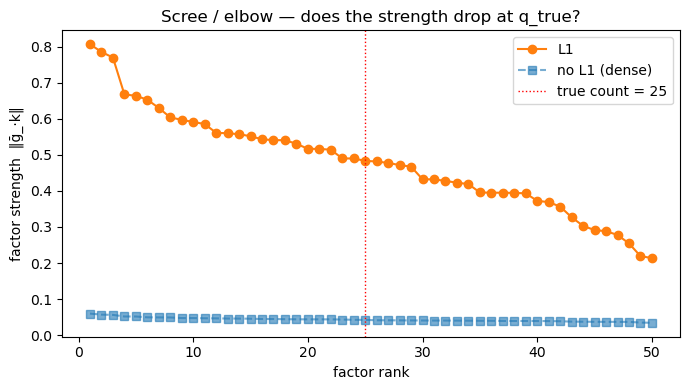

L1 elbow (largest strength drop) at rank 3   (true 25)


In [6]:
# Factor strength = averaged-gradient L2 norm per column (continuous evidence, pre-mask).
str_l1   = ft_l1.gbar_.norm(dim=0).cpu().numpy()
str_dense = ft_dense.gbar_.norm(dim=0).cpu().numpy()
str_l1.sort();   str_l1   = str_l1[::-1]
str_dense.sort(); str_dense = str_dense[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, Q_FIT + 1), str_l1, "o-", color="C1", label="L1")
ax.plot(range(1, Q_FIT + 1), str_dense, "s--", color="C0", alpha=0.6, label="no L1 (dense)")
ax.axvline(Q_TRUE, color="r", lw=1, ls=":", label=f"true count = {Q_TRUE}")
ax.set_xlabel("factor rank"); ax.set_ylabel("factor strength  ‖ḡ_·k‖")
ax.set_title("Scree / elbow — does the strength drop at q_true?")
ax.legend()
plt.tight_layout(); plt.show()

# simple automatic elbow: largest drop in sorted strength
drops = str_l1[:-1] - str_l1[1:]
print(f"L1 elbow (largest strength drop) at rank {int(np.argmax(drops))+1}   (true {Q_TRUE})")

## Choosing λ — held-out predictive deviance

No ground truth on real data, so pick λ by **prediction**: hold out some cells, fit the path on
the rest, and score Poisson deviance on the held-out cells (encode them with the parameter-free
encoder → predict → deviance). Rule: take the **largest λ (sparsest model) whose held-out
deviance is within 1% of the best** — as sparse as we can get without hurting the fit. We overlay
the ground-truth support F1 only to check the criterion lands in a sensible place.

In [7]:
# Held-out split: fit the path on held-in cells, score deviance on held-out cells.
torch.manual_seed(SEED)
perm = torch.randperm(N, device=device)
tr, te = perm[:400], perm[400:]
Ytr, Yte = Y[tr], Y[te]

# warm ONCE on held-in cells (steps=0 → warm-start only, reused across the λ-path)
warm_tr = SparseZQEFitter(
    fresh_model(Q_FIT, P, WZ_SCALE),
    encoder_factory=lambda g: MapEncoderPoissonNewton(g, lam=1.0, max_iter=30),
    l1=L1, l2=L2, steps=0, device=device, seed=SEED, verbose=False).fit(Ytr).warm_model_

def heldout_nll(model):
    """Mean held-out Poisson NLL: encode held-out cells with the Poisson-MAP encoder, score
    their counts (lower = better)."""
    enc = MapEncoderPoissonNewton(model, lam=1.0, max_iter=30)
    with torch.no_grad():
        z, _, _ = enc.sample(Yte)
        return float(-model.log_prob(Yte, z=z).sum(-1).mean())

lam_grid = np.geomspace(0.30, 0.012, 6)   # large → small
path = []
for lam in lam_grid:
    ft = SparseZQEFitter(
        fresh_model(Q_FIT, P, WZ_SCALE),
        encoder_factory=lambda g: MapEncoderPoissonNewton(g, lam=1.0, max_iter=30),
        l1=float(lam), l2=L2, steps=250, refine_lr=0.2, revive_jitter=0.0,
        warm_model=warm_tr, device=device, seed=SEED, verbose=False).fit(Ytr)
    m = ft.mask_.cpu()
    _, _, F_, _ = align_and_score(ft.model.wz.detach().cpu(), m, W_true)
    path.append(dict(lam=float(lam), nll=heldout_nll(ft.model),
                     live=int((m.sum(0) > 0).sum()), F1=float(F_.mean())))
    print(f"λ={lam:.3f}  held-out NLL={path[-1]['nll']:8.2f}  "
          f"live={path[-1]['live']:2d}  F1(truth)={path[-1]['F1']:.2f}")

# selection rule: largest λ (grid is large→small, so first qualifying) within 1% of best NLL
nll = np.array([p["nll"] for p in path])
within = nll <= nll.min() + 0.01 * abs(nll.min())
lam_star = path[int(np.argmax(within))]
print(f"\nchosen λ = {lam_star['lam']:.3f}   "
      f"(held-out NLL={lam_star['nll']:.2f}, live={lam_star['live']}, F1={lam_star['F1']:.2f})")

λ=0.300  held-out NLL= 1536.49  live= 4  F1(truth)=0.02


λ=0.158  held-out NLL= 1475.95  live=12  F1(truth)=0.11


λ=0.083  held-out NLL= 1391.12  live=37  F1(truth)=0.38


λ=0.043  held-out NLL= 1361.03  live=50  F1(truth)=0.42


λ=0.023  held-out NLL= 1354.30  live=50  F1(truth)=0.27


λ=0.012  held-out NLL= 1350.88  live=50  F1(truth)=0.17

chosen λ = 0.043   (held-out NLL=1361.03, live=50, F1=0.42)


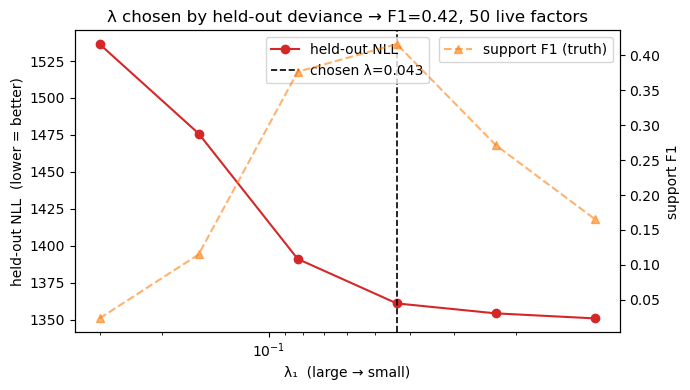

In [8]:
lams = [p["lam"] for p in path]
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(lams, [p["nll"] for p in path], "o-", color="C3", label="held-out NLL")
ax1.axvline(lam_star["lam"], color="k", ls="--", lw=1.2, label=f"chosen λ={lam_star['lam']:.3f}")
ax1.set_xscale("log"); ax1.invert_xaxis()          # large λ (sparse) → small λ (dense)
ax1.set_xlabel("λ₁  (large → small)"); ax1.set_ylabel("held-out NLL  (lower = better)")
ax1.legend(loc="upper center")
ax2 = ax1.twinx()
ax2.plot(lams, [p["F1"] for p in path], "^--", color="C1", alpha=0.6, label="support F1 (truth)")
ax2.set_ylabel("support F1")
ax2.legend(loc="upper right")
ax1.set_title(f"λ chosen by held-out deviance → F1={lam_star['F1']:.2f}, "
              f"{lam_star['live']} live factors")
plt.tight_layout(); plt.show()